# Detección de Plagio en Código Fuente

Pipeline completo para detectar plagio entre archivos `.c` y `.java` del dataset SOCO-2014.  
Combina embeddings semánticos (UniXcoder), métricas de similitud textual y un clasificador Random Forest.

---

## 1. Carga de Archivos

In [1]:
from pathlib import Path
import pandas as pd

c_files = list(Path("soco-dataset/c").glob("*.c"))
java_files = list(Path("soco-dataset/java").glob("*.java"))
files = c_files + java_files

print(f"Archivos C: {len(c_files)} | Java: {len(java_files)} | Total: {len(files)}")

Archivos C: 79 | Java: 259 | Total: 338


## 2. Embeddings Semánticos con UniXcoder

Cargamos `microsoft/unixcoder-base` para generar representaciones densas del código fuente. Cada archivo se tokeniza y se promedia el último estado oculto como vector de embedding.

In [2]:
from transformers import AutoTokenizer, AutoModel
import torch

# Utilizar tokenizer y modelo de embedding UniXcoder
tokenizer = AutoTokenizer.from_pretrained("microsoft/unixcoder-base")
embedding_model = AutoModel.from_pretrained("microsoft/unixcoder-base")

print("Successfully imported tokenizer and model UNIXCODER")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Successfully imported tokenizer and model UNIXCODER


In [14]:
def tokenize_and_embed(filepath):
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        code = f.read()

    # UniXCoder pide un máximo de 512 tokens por archivo. Como existen
    # archivos con más tokens, se separan los 
    input_ids = tokenizer(code, add_special_tokens=False)["input_ids"]

    # Dividir en bloques de hasta 510 tokens (+ <s> y </s> = 512, límite de UniXcoder)
    chunk_size = 510

    # Indica qué rango de tokens se tomará en cuenta
    chunks = [input_ids[i:i + chunk_size] for i in range(0, len(input_ids), chunk_size)]

    chunk_embeddings = []
    chunk_lengths = []

    # Para cada chunk
    for chunk in chunks:
        ids = [tokenizer.cls_token_id] + chunk + [tokenizer.sep_token_id]
        input_tensor = torch.tensor([ids])
        attention_mask = torch.ones_like(input_tensor)

        with torch.no_grad():
            outputs = embedding_model(input_ids=input_tensor, attention_mask=attention_mask)

        chunk_embeddings.append(outputs.last_hidden_state.mean(dim=1))
        chunk_lengths.append(len(chunk))

    # Promediar los embeddings de cada bloque, ponderando por su tamaño
    weights = torch.tensor(chunk_lengths, dtype=torch.float).unsqueeze(1)
    stacked = torch.cat(chunk_embeddings, dim=0)
    embedding = (stacked * weights).sum(dim=0, keepdim=True) / weights.sum()

    return embedding

In [15]:
from tqdm.notebook import tqdm
import numpy as np

def save_embeddings(files):
    embeddings = []
    for file in tqdm(files, desc="Generating embeddings", unit="file"):
        embeddings.append(tokenize_and_embed(file))
    return np.array(embeddings).squeeze(1)

In [16]:
embeddings = save_embeddings(files)

Generating embeddings:   0%|          | 0/338 [00:00<?, ?file/s]

## 3. Matriz de Similitud de Coseno

Calculamos la similitud coseno entre todos los pares de embeddings para obtener una medida de parecido semántico global entre archivos.

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(embeddings)

## 4. Construcción de Pares y Ranking

Generamos todos los pares únicos de archivos, los ordenamos por similitud descendente y construimos el DataFrame base que alimentará el extractor de features.

In [18]:
def sort_similarities(files, embeddings, sim_matrix):
    pairs = []
    
    for i in range(len(embeddings)):
        for j in range(i + 1, len(embeddings)):
            plagiarism = 0
            if sim_matrix[i][j] > 0.8:
                plagiarism = 1
            pairs.append((files[i], files[j], round(float(sim_matrix[i][j]), 4), plagiarism))
    
    pairs.sort(key=lambda x: x[2], reverse=True)

    return pairs

In [19]:
def create_dataframe(pairs, num_of_pairs):
    data_frame = pd.DataFrame(
        pairs[:num_of_pairs],
        columns=["file1", "file2", "similarity", "plagiarism_suspected"]
    )
    data_frame["file1"] = data_frame["file1"].apply(lambda x: x.name)
    data_frame["file2"] = data_frame["file2"].apply(lambda x: x.name)
    return data_frame

In [20]:
pairs = sort_similarities(files, embeddings, sim_matrix)

dataframe = create_dataframe(pairs, 60000)

display(dataframe.head(100))

,file1,file2,similarity,plagiarism_suspected
0,005.java,006.java,1.0000,1
1,015.java,023.java,0.9990,1
2,250.java,159.java,0.9944,1
3,024.java,016.java,0.9940,1
4,043.java,251.java,0.9932,1
...,...,...,...,...
95,031.c,025.c,0.9134,1
96,032.c,026.c,0.9134,1
97,009.c,045.c,0.9134,1
98,040.c,007.c,0.9132,1


## 5. Extracción de Features de Similitud Textual

Cargamos el ground truth real desde los archivos `.qrel` del dataset SOCO y calculamos múltiples métricas de similitud textual (Jaccard, Dice, Levenshtein, Jaro-Winkler, coseno BoW) para cada par de archivos.

In [21]:
import subprocess
subprocess.run(["pip", "install", "rapidfuzz", "-q"], capture_output=True)

import re
import math
import pandas as pd
import numpy as np
from collections import Counter
from pathlib import Path
from rapidfuzz.distance import Levenshtein as RapidLev
from rapidfuzz.distance import Jaro, JaroWinkler

def load_ground_truth():
    plagiarism_pairs = set()
    for qrel_path in ["soco-dataset/SOCO14-c.qrel", "soco-dataset/SOCO14-java.qrel"]:
        with open(qrel_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 2:
                    a, b = parts
                    plagiarism_pairs.add((a, b))
                    plagiarism_pairs.add((b, a))
    return plagiarism_pairs

ground_truth = load_ground_truth()
print(f"Pares de plagio en ground truth: {len(ground_truth) // 2}")

Pares de plagio en ground truth: 110


In [22]:

def read_code(filename):
    for folder in ["soco-dataset/c", "soco-dataset/java"]:
        path = Path(folder) / filename
        if path.exists():
            with open(path, "r", encoding="utf-8", errors="ignore") as f:
                return f.read()
    return ""

def normalize_code(code):
    code = re.sub(r"//.*?\n|/\*.*?\*/", " ", code, flags=re.DOTALL)
    return re.sub(r"\s+", " ", code).strip().lower()

def tokenize(code):
    return re.findall(r"\w+", code)

def get_ngrams(tokens, n):
    return list(zip(*[tokens[i:] for i in range(n)]))

def jaccard(seq_a, seq_b):
    set_a, set_b = set(seq_a), set(seq_b)
    if not set_a and not set_b:
        return 1.0
    inter = len(set_a & set_b)
    union = len(set_a | set_b)
    return inter / union if union > 0 else 0.0

def dice(seq_a, seq_b):
    set_a, set_b = set(seq_a), set(seq_b)
    if not set_a and not set_b:
        return 1.0
    inter = len(set_a & set_b)
    denom = len(set_a) + len(set_b)
    return 2 * inter / denom if denom > 0 else 0.0

def cosine_bow(tokens_a, tokens_b):
    ca, cb = Counter(tokens_a), Counter(tokens_b)
    vocab = set(ca) | set(cb)
    dot = sum(ca[w] * cb[w] for w in vocab)
    mag_a = math.sqrt(sum(v ** 2 for v in ca.values()))
    mag_b = math.sqrt(sum(v ** 2 for v in cb.values()))
    return dot / (mag_a * mag_b) if mag_a and mag_b else 0.0

def compute_all_features(file1, file2):
    code1 = normalize_code(read_code(file1))
    code2 = normalize_code(read_code(file2))
    tokens1 = tokenize(code1)
    tokens2 = tokenize(code2)

    # Limitar tokens para que Levenshtein/Jaro sean razonablemente rápidos
    t1 = " ".join(tokens1[:300])
    t2 = " ".join(tokens2[:300])

    lev_dist = RapidLev.distance(t1, t2)
    max_len = max(len(t1), len(t2))
    lev_ratio = 1.0 - (lev_dist / max_len) if max_len > 0 else 1.0

    return {
        "jaccard_tokens":    jaccard(tokens1, tokens2),
        "jaccard_bigrams":   jaccard(get_ngrams(tokens1, 2), get_ngrams(tokens2, 2)),
        "jaccard_trigrams":  jaccard(get_ngrams(tokens1, 3), get_ngrams(tokens2, 3)),
        "dice":              dice(tokens1, tokens2),
        "levenshtein_dist":  lev_dist,
        "levenshtein_ratio": lev_ratio,
        "jaro":              Jaro.similarity(t1, t2),
        "jaro_winkler":      JaroWinkler.similarity(t1, t2),
        "cosine_similarity": cosine_bow(tokens1, tokens2),
    }

print("Funciones de similitud definidas correctamente.")


Funciones de similitud definidas correctamente.


In [23]:
from tqdm.notebook import tqdm

# ── Parámetros ──────────────────────────────────────────────────────────────
PLAGIARISM_THRESHOLD = 0.70   # promedio de métricas >= threshold → plagio
N_NEGATIVES          = 12000  # negativos a samplear

# Métricas en escala 0-1 que entran al promedio (mayor = más similar)
AVG_METRICS = [
    "jaccard_tokens", "jaccard_bigrams", "jaccard_trigrams",
    "dice", "levenshtein_ratio",
    "jaro", "jaro_winkler",
    "cosine_similarity", "embedding_cosine"
]

# ── Cachear tokens una sola vez por archivo ─────────────────────────────────
print("Preprocesando y cacheando archivos...")
all_files = set(dataframe["file1"]) | set(dataframe["file2"])
file_tokens_cache = {}
for fname in tqdm(all_files, desc="Tokenizando archivos"):
    code = normalize_code(read_code(fname))
    file_tokens_cache[fname] = tokenize(code)

def compute_features_cached(f1, f2, emb_cos):
    tokens1 = file_tokens_cache.get(f1, [])
    tokens2 = file_tokens_cache.get(f2, [])

    t1 = " ".join(tokens1[:100])
    t2 = " ".join(tokens2[:100])

    lev_dist = RapidLev.distance(t1, t2)
    max_len  = max(len(t1), len(t2))
    lev_ratio = 1.0 - (lev_dist / max_len) if max_len > 0 else 1.0

    return {
        "code1_id":          f1,
        "code2_id":          f2,
        "jaccard_tokens":    jaccard(tokens1, tokens2),
        "jaccard_bigrams":   jaccard(get_ngrams(tokens1, 2), get_ngrams(tokens2, 2)),
        "jaccard_trigrams":  jaccard(get_ngrams(tokens1, 3), get_ngrams(tokens2, 3)),
        "dice":              dice(tokens1, tokens2),
        "levenshtein_dist":  lev_dist,
        "levenshtein_ratio": lev_ratio,
        "jaro":              Jaro.similarity(t1, t2),
        "jaro_winkler":      JaroWinkler.similarity(t1, t2),
        "cosine_similarity": cosine_bow(tokens1, tokens2),
        "embedding_cosine":  round(float(emb_cos), 6),
    }

# ── Calcular features para todos los pares ─────────────────────────────────
print("\nCalculando features para todos los pares...")
rows = []
for _, row in tqdm(dataframe.iterrows(), total=len(dataframe), desc="Procesando pares"):
    record = compute_features_cached(row["file1"], row["file2"], row["similarity"])
    rows.append(record)

df_features = pd.DataFrame(rows)

# ── Promediar métricas y asignar label ──────────────────────────────────────
df_features["similarity_avg"] = df_features[AVG_METRICS].mean(axis=1)
df_features["label"] = (df_features["similarity_avg"] >= PLAGIARISM_THRESHOLD).astype(int)

print(f"\nThreshold: promedio de métricas >= {PLAGIARISM_THRESHOLD}")
print(f"  Plagio    (label=1): {df_features['label'].sum()}")
print(f"  No plagio (label=0): {(df_features['label'] == 0).sum()}")

# ── Balancear: todos los positivos + N_NEGATIVES negativos ─────────────────
positives = df_features[df_features["label"] == 1]
negatives = df_features[df_features["label"] == 0]
negatives_sampled = negatives.sample(n=min(N_NEGATIVES, len(negatives)), random_state=42)
df_balanced = pd.concat([positives, negatives_sampled]).reset_index(drop=True)

print(f"\nDataset final:")
print(f"  Plagio    (label=1): {len(positives)}")
print(f"  No plagio (label=0): {len(negatives_sampled)}")
print(f"  Total:               {len(df_balanced)}")

# ── Guardar CSV ─────────────────────────────────────────────────────────────
COLS = [
    "code1_id", "code2_id", "label",
    "jaccard_tokens", "jaccard_bigrams", "jaccard_trigrams",
    "dice", "levenshtein_dist", "levenshtein_ratio",
    "jaro", "jaro_winkler", "cosine_similarity", "embedding_cosine",
    "similarity_avg"
]
dataset = df_balanced[COLS]

CSV_PATH = "plagiarism_dataset.csv"
dataset.to_csv(CSV_PATH, index=False)

print(f"\nDataset guardado: {CSV_PATH}")
print(f"  Filas: {len(dataset)} | Columnas: {len(dataset.columns)}")
display(dataset.head(10))

Preprocesando y cacheando archivos...


Tokenizando archivos:   0%|          | 0/338 [00:00<?, ?it/s]


Calculando features para todos los pares...


Procesando pares:   0%|          | 0/56953 [00:00<?, ?it/s]


Threshold: promedio de métricas >= 0.7
  Plagio    (label=1): 53
  No plagio (label=0): 56900

Dataset final:
  Plagio    (label=1): 53
  No plagio (label=0): 12000
  Total:               12053

Dataset guardado: plagiarism_dataset.csv
  Filas: 12053 | Columnas: 14


,code1_id,code2_id,label,jaccard_tokens,jaccard_bigrams,jaccard_trigrams,dice,levenshtein_dist,levenshtein_ratio,jaro,jaro_winkler,cosine_similarity,embedding_cosine,similarity_avg
0,005.java,006.java,1,1.000000,0.994129,0.990783,1.000000,0,1.000000,1.000000,1.000000,0.999918,1.0000,0.998315
1,015.java,023.java,1,1.000000,1.000000,1.000000,1.000000,0,1.000000,1.000000,1.000000,1.000000,0.9990,0.999889
2,250.java,159.java,1,0.970149,0.961783,0.964706,0.984848,32,0.916449,0.828334,0.897000,0.999484,0.9944,0.946350
3,024.java,016.java,1,0.991228,0.956349,0.936842,0.995595,0,1.000000,1.000000,1.000000,0.997690,0.9940,0.985745
4,043.java,251.java,1,0.929825,0.891566,0.872340,0.963636,95,0.856278,0.845849,0.907509,0.984751,0.9932,0.916106
5,051.c,045.c,1,0.812500,0.625000,0.556818,0.896552,103,0.792339,0.843280,0.905968,0.937635,0.9889,0.817666
6,209.java,201.java,1,0.937500,0.887097,0.857143,0.967742,23,0.964119,0.937955,0.962773,0.992067,0.9857,0.943566
7,073.c,074.c,1,0.868687,0.672831,0.587786,0.929730,194,0.698758,0.866055,0.919633,0.969153,0.9831,0.832859
8,014.java,021.java,1,1.000000,0.989011,0.979381,1.000000,0,1.000000,1.000000,1.000000,0.999298,0.9799,0.994177
9,195.java,218.java,1,0.651376,0.456790,0.377049,0.788889,87,0.855000,0.866111,0.919666,0.915368,0.9785,0.756528


## 6. Modelo de Clasificación: Random Forest con SMOTE-ENN

Entrenamos un clasificador Random Forest con las 10 features de similitud. Para manejar el fuerte desbalance de clases, aplicamos SMOTE-ENN exclusivamente sobre el conjunto de entrenamiento (sin data leakage).

Distribución ANTES de SMOTE-ENN (train):
  label=0: 9600
  label=1: 42

Distribución DESPUÉS de SMOTE-ENN (train):
  label=0: 9494
  label=1: 9597
  Total train: 19091

=== Classification Report (test original) ===
              precision    recall  f1-score   support

   No Plagio       1.00      1.00      1.00      2400
      Plagio       1.00      1.00      1.00        11

    accuracy                           1.00      2411
   macro avg       1.00      1.00      1.00      2411
weighted avg       1.00      1.00      1.00      2411

ROC-AUC: 1.0000


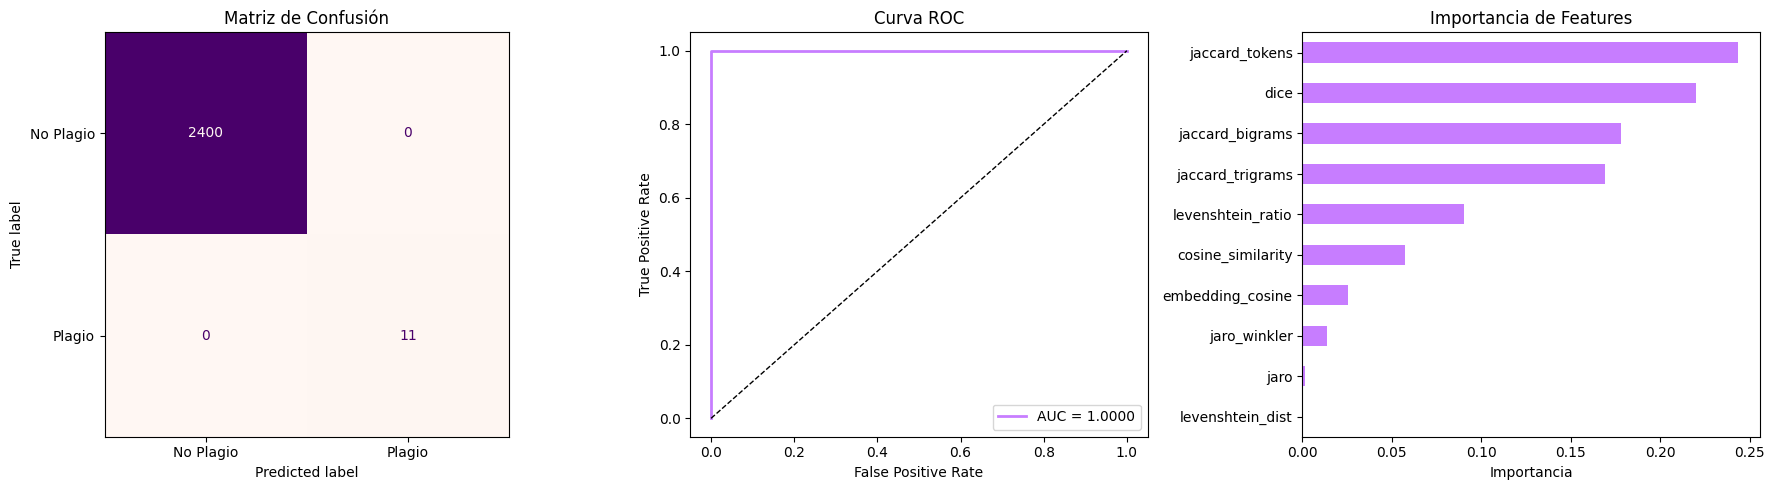

In [24]:
import subprocess
subprocess.run(["pip", "install", "imbalanced-learn", "-q"], capture_output=True)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from imblearn.combine import SMOTEENN

# ── Cargar dataset ──────────────────────────────────────────────────────────
dataset = pd.read_csv("plagiarism_dataset.csv")

FEATURE_COLS = [
    "jaccard_tokens", "jaccard_bigrams", "jaccard_trigrams",
    "dice", "levenshtein_dist", "levenshtein_ratio",
    "jaro", "jaro_winkler", "cosine_similarity", "embedding_cosine"
]

X = dataset[FEATURE_COLS].values
y = dataset["label"].values

# ── Split ANTES de SMOTE-ENN (evitar data leakage) ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Distribución ANTES de SMOTE-ENN (train):")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  label={u}: {c}")

# ── Aplicar SMOTE-ENN solo en train ────────────────────────────────────────
smote_enn = SMOTEENN(random_state=42)
X_train_res, y_train_res = smote_enn.fit_resample(X_train, y_train)

print("\nDistribución DESPUÉS de SMOTE-ENN (train):")
unique, counts = np.unique(y_train_res, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  label={u}: {c}")
print(f"  Total train: {len(y_train_res)}")

# ── Entrenar modelo ─────────────────────────────────────────────────────────
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_res, y_train_res)

# ── Evaluar sobre test original (sin SMOTE-ENN) ─────────────────────────────
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n=== Classification Report (test original) ===")
print(classification_report(y_test, y_pred, target_names=["No Plagio", "Plagio"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# ── Gráficas ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["No Plagio", "Plagio"]).plot(
    ax=axes[0], cmap="RdPu", colorbar=False
)
axes[0].set_title("Matriz de Confusión")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#c77dff", lw=2,
             label=f"AUC = {roc_auc_score(y_test, y_proba):.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC")
axes[1].legend()

importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind="barh", ax=axes[2], color="#c77dff")
axes[2].set_title("Importancia de Features")
axes[2].set_xlabel("Importancia")

plt.tight_layout()
plt.show()